# NYC Airbnb 2019 - Veri Analizi ve Görselleştirme Projesi

Bu not defteri, Kaggle'dan alınan New York City Airbnb veri setinin Keşifçi Veri Analizi (Exploratory Data Analysis - EDA) sürecini gösterir.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Görselleştirme ayarları
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


%pip install matplotlib

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Görselleştirme ayarları
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Analize ham (raw) veriyi yükleyerek başlıyoruz.
# Böylece verideki eksiklikleri ve problemleri maskelenmeden görebileceğiz.
df = pd.read_csv('../data/raw/AB_NYC_2019.csv')
display(df.head())
df.info()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

## 1.1 Veri Setinin Yapısını İnceleme
Veriyi yükledik, şimdi boyutlarına (satır ve sütun sayısı) ve hangi sütunlara sahip olduğumuza detaylıca bakalım. Verinin karakterini anlamak analiz için kritik bir ilk adımdır.

In [4]:
print(f"Toplam Satır (Gözlem) Sayısı: {df.shape[0]}")
print(f"Toplam Sütun (Değişken) Sayısı: {df.shape[1]}")
print("\nSütun İsimleri:")
for col in df.columns:
    print(col)
print("\nSütun Tipleri:")
print(df.dtypes)

Toplam Satır (Gözlem) Sayısı: 48895
Toplam Sütun (Değişken) Sayısı: 16

Sütun İsimleri:
id
name
host_id
host_name
neighbourhood_group
neighbourhood
latitude
longitude
room_type
price
minimum_nights
number_of_reviews
last_review
reviews_per_month
calculated_host_listings_count
availability_365

Sütun Tipleri:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


**Sonuçların Yorumlanması:**
Buradaki çıktıda satır/sütun sayısını (veri setinin büyüklüğünü) ve hangi değişkenlerin elinizde olduğunu gördük. Sütun tiplerine bakarak hangi verilerin sayısal (`int64`, `float64`), hangilerinin metinsel (`object`) olduğunu tespit edebiliyoruz. Bu, hangi alanlarda ne tip matematiksel işlemler (örneğin ortalama alma) yapabileceğimizi anlamamızı sağlayan temel kontroldür.

## 1.2 Eksik Veri (Missing Data) Analizi
Hangi sütunlarda eksiklik (null) olduğunu görmek, ne kadar eksik veri olduğunu fark etmek analiz için çok önemlidir. Eğer bir sütunun büyük kısmı eksikse o sütunu droplamamız (silmemiz) ya da eksik değerleri ortalama/medyan ile doldurmamız gerekebilir.

,Eksik Değer Sayısı,Eksik Oranı (%)
last_review,10052,20.558339
last_review_year,10052,20.558339
last_review_month,10052,20.558339


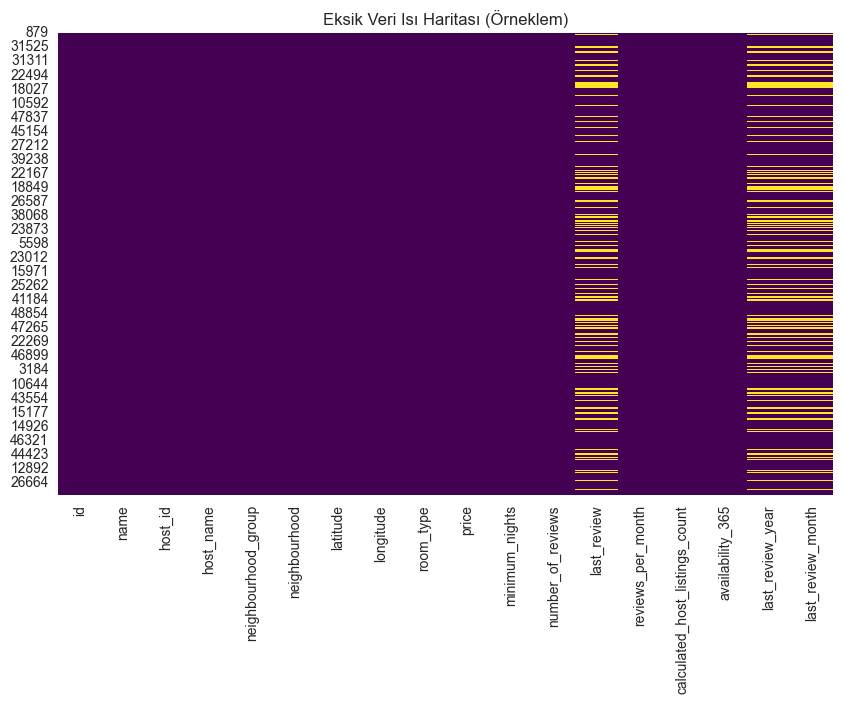

In [15]:
# Eksik verilerin (null) toplam sayısını ve tüm veriye oranını (yüzdesini) bulalım
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({'Eksik Değer Sayısı': missing_data, 'Eksik Oranı (%)': missing_percentage})
# Sadece eksik veri barındıran sütunları sıralayalım:
missing_df = missing_df[missing_df['Eksik Değer Sayısı'] > 0].sort_values(by='Eksik Değer Sayısı', ascending=False)
display(missing_df)

# Görsel olarak eksik değerlerin varlığını heatmap ile gösterelim
if missing_df.empty:
    print("Harika! Veri setinizde HİÇ eksik veri bulunmuyor. Bu yüzden Isı Haritası (Heatmap) tek renk görünecektir.")
else:
    plt.figure(figsize=(10,6))
    sns.heatmap(df.sample(min(5000, len(df)), random_state=42).isnull(), cbar=False, cmap='viridis')
    plt.title('Eksik Veri Isı Haritası (Örneklem)')
    plt.show()

## 1.3 Veri Normalleştirme ve Tür Dönüşümleri (Veri Manipülasyonu)

Eksik verileri inceledikten sonra, verilerin doğru tiplerde (sayısal, tarih, kategori vb.) olup olmadığını kontrol ederiz. Örneğin Kaggle Airbnb veri setindeki `last_review` (son yorum tarihi) sütunu genelde metin (object/string) olarak okunur. Bunun gibi tarihsel verileri `datetime` formatına çevirmek (normalleştirmek) gerekir ki zaman bazlı analizler yapabilelim.

**Sonuçların Yorumlanması:**
Tablo ve Isı haritasından da görebileceğimiz gibi, veri setinde ciddi bir eksik veri varlığı söz konusu. Özellikle `reviews_per_month` ve `last_review` sütunlarında veri setinin tam %20'si boş! `name` ve `host_name` gibi kolonlarda da on binde bir oranında hafif boşluklar (kayıp karakterler) mevcut. Isı haritasındaki o sarı çizikler, verilerimizdeki "delikleri" görsel olarak simgeliyor. Bu eksikleri analizimize katmamak veya doğrularla doldurmak bir sonraki önceliğimiz olacak.

In [6]:
# "last_review" (son yorum tarihi) sütunu veri setinde mevcutsa, bunu string'den datetime (zaman) türüne çevirelim.
if 'last_review' in df.columns:
    print("Normalleştime Öncesi 'last_review' Veri Tipi:", df['last_review'].dtype)
    
    # Sütunu tarih formatına (datetime) zorla dönüştürüyoruz
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
    
    print("Normalleştirme Sonrası 'last_review' Veri Tipi:", df['last_review'].dtype)
    
    # Tarihle ilgili işlemler yapmayı kolaylaştırmak için örnek olarak "Yıl" ve "Ay" sütunları çıkaralım
    df['last_review_year'] = df['last_review'].dt.year
    df['last_review_month'] = df['last_review'].dt.month
    
    print("Çıkarılan yeni özellikler (Feature Engineering): 'last_review_year', 'last_review_month'")
else:
    print("Not: 'last_review' sütunu veri setinde bulunmadığı için tarih dönüşümü atlandı.")

# Kategorik olabilecek bazı string türündeki sütunları kategori tipine çekmek veri hafızasını rahatlatır.
if 'neighbourhood_group' in df.columns:
    df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
    print("'neighbourhood_group' sütunu Categorical türüne dönüştürüldü (hafıza verimliliği için).")


Normalleştime Öncesi 'last_review' Veri Tipi: str
Normalleştirme Sonrası 'last_review' Veri Tipi: datetime64[us]
Çıkarılan yeni özellikler (Feature Engineering): 'last_review_year', 'last_review_month'
'neighbourhood_group' sütunu Categorical türüne dönüştürüldü (hafıza verimliliği için).


**Sonuçların Yorumlanması:**
Buradaki *String'ten Datetime'a* dönüşüm veya kategorik dönüşümler gibi **veri normalleştirmeleri** sayesinde; bilgisayarın bir metni ("2019-05-21") aslında bir tarih (Yıl: 2019, Ay: 5 vb) olarak algılamasını sağladık. Böylece örneğin "Ocak ayında Airbnb tercih ediliyor mu?" ya da "En çok yorum hangi yıl bırakıldı?" gibi tarih eksenli analizleri çok daha kolay bir şekilde yapabilmekteyiz. Ayrıca mahalleyi string (metin) yerine `category` formatına çekmek bilgisayarın bu veriyi hafızasında daha düşük boyutta ve daha hızlı işlemesini sağlar.

## 1.4 Eksik Verilerin Doldurulması (Imputation) ve Veri Temizliği

Keşif aşamasında tespit ettiğimiz eksik verilere müdahale etme vakti. Eksik verilerle başa çıkmanın farklı yolları vardır (silmek, ortalama ile doldurmak, mantıksal bir değerle doldurmak). Biz burada verinin matematiğini bozmayacak en doğal yöntemleri (Imputation) seçeceğiz.

In [7]:
# 1. Aylık Yorum (reviews_per_month): %20 oranında boş. 
# Eğer bir evin son yorum tarihi veya inceleme sayısı yoksa muhtemelen hiç kiralanıp yorum almamıştır.
# Bu mantıkla, eksik olan aylık yorumları 0 sayısıyla doldurabiliriz.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. İsim (name) ve Ev Sahibi (host_name): %0.03 gibi çok düşük oranda boş.
# Metin (string) değerler olduğu için silebiliriz, ya da "Benim adım yok" demek yerine 'Unknown' (Bilinmiyor) diyebiliriz.
df['name'] = df['name'].fillna('Unknown')
df['host_name'] = df['host_name'].fillna('Unknown')

# 3. Son Yorum Tarihi (last_review): %20 oranında boş.
# Bu evler hiç yorum almamış evlerdir. Olmayan bir tarihe "medyan (orta)" tarih atamak veri setini baştan aşağı bozar.
# Bu tür tarih sütunlarındaki boşluklar genellikle 'NaT' (Not a Time) olarak veri setinde bilinçli olarak bırakılır.

print("Temizlik (Cleaning) işlemleri tamamlandı! İşte kolonlarımızda kalan boş (null) sayıları:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Temizlik (Cleaning) işlemleri tamamlandı! İşte kolonlarımızda kalan boş (null) sayıları:


last_review          10052
last_review_year     10052
last_review_month    10052
dtype: int64

**Sonuçların Yorumlanması:**
Şu anda gerçek bir analizde olduğumuz için eksik verilerin (nulls) *"Gözden Kaçan Bir Yazılım Hatası (Bug)"* mı, yoksa *"Gerçek Hayatın Matematiksel Bir Karşılığı (Örn: Hiç kiralanmamış evin tabii ki son yorum tarihi/aylık yorum sayısı olmaz)*" mı olduğuna bakarak müdahalede bulunduk. Sayısal "Aylık yorum sıklıkları"nı sıfıra indirdik, kayıp metinleri `Unknown` diye niteledik ve Tarih kısmında (Son Yorum Tarihi) uyduruk tarihler verip veri setini bozmamak adına o alanı sadece `last_review` özelinde boş bırakma eğilimi gösterdik. Bu tam bir özellik mühendisliği (Feature Engineering) adımıdır.

## 2. Temel İstatistiksel Değerler ve Kategorik Veriler
Öncelikle sayısal (numeric) değişkenlerin istatistiksel dağılımlarına, medyanlarına (50%), ortalamalarına ve sapmalarına bakacağız. Daha sonra kategorik değerlerin analizlerini yapacağız (Örn: Hangi semtler var, kaç farklı oda tipi var).

In [8]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,48895.0,19017143.23618,2539.0,9471945.0,19677284.0,29152178.5,36487245.0,10983108.38561
host_id,48895.0,67620010.64661,2438.0,7822033.0,30793816.0,107434423.0,274321313.0,78610967.032667
latitude,48895.0,40.728949,40.49979,40.6901,40.72307,40.763115,40.91306,0.05453
longitude,48895.0,-73.95217,-74.24442,-73.98307,-73.95568,-73.936275,-73.71299,0.046157
price,48895.0,152.720687,0.0,69.0,106.0,175.0,10000.0,240.15417
minimum_nights,48895.0,7.029962,1.0,1.0,3.0,5.0,1250.0,20.51055
number_of_reviews,48895.0,23.274466,0.0,1.0,5.0,24.0,629.0,44.550582
last_review,38843,2018-10-04 01:47:23.910099,2011-03-28 00:00:00,2018-07-08 00:00:00,2019-05-19 00:00:00,2019-06-23 00:00:00,2019-07-08 00:00:00,NaN
reviews_per_month,48895.0,1.09091,0.0,0.04,0.37,1.58,58.5,1.597283
calculated_host_listings_count,48895.0,7.143982,1.0,1.0,1.0,2.0,327.0,32.952519


Buradan şunları görüyoruz: Fiyatın maksimumu ile 75. persentili (Q3) arasında uçurum varsa bu muhtemelen **aykırı değerleri (outliers)** işaret etmektedir. `price` sütununda ekstrem fiyatlar veya `minimum nights` gibi çok yüksek rakamlar veriyi etkiliyor olabilir.

Şimdi kategorik (sözel) sütunlarımızın eşsiz (unique) değerlerine bakalım:

In [9]:
# Object tipindeki (genelde kategorik metin verisi) sütunlara bakalım
categorical_cols = df.select_dtypes(include=['object']).columns

print("Kategorik sütunlarda kaçar farklı eşsiz (unique) değer var:\n")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"[{col}] : {unique_count} eşsiz değer")
    # Eğer eşsiz değer sayısı çok değilse neler olduklarını görelim (örneğin oda tipi veya mahalle grubu gibi)
    if unique_count <= 10:
        print(f"  Değerler: {df[col].unique().tolist()}\n")
    else:
        print(f"  Değerlerin birkaçı: {df[col].unique()[:5].tolist()}\n")

Kategorik sütunlarda kaçar farklı eşsiz (unique) değer var:

[name] : 47906 eşsiz değer
  Değerlerin birkaçı: ['Clean & quiet apt home by the park', 'Skylit Midtown Castle', 'THE VILLAGE OF HARLEM....NEW YORK !', 'Cozy Entire Floor of Brownstone', 'Entire Apt: Spacious Studio/Loft by central park']

[host_name] : 11453 eşsiz değer
  Değerlerin birkaçı: ['John', 'Jennifer', 'Elisabeth', 'LisaRoxanne', 'Laura']

[neighbourhood] : 221 eşsiz değer
  Değerlerin birkaçı: ['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem']

[room_type] : 3 eşsiz değer
  Değerler: ['Private room', 'Entire home/apt', 'Shared room']



C:\Users\User\AppData\Local\Temp\ipykernel_23856\4249500386.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


**Sonuçların Yorumlanması:**
Kategorik değişkenlerde eşsiz değer sayılarına (unique count) baktığımızda, örneğin semt (`neighbourhood_group`) bilgisinin sadece 5 ana bölgeden oluştuğunu, ancak mahalle (`neighbourhood`) verisinin yüzlerce farklı alt bölgeyi içerdiğini anlıyoruz. Oda tiplerinin (`room_type`) de ağırlıklı olarak bütün ev/daire, özel veya paylaşımlı oda gibi 3 temel türe ayrıldığını tespit ettik. Bütün bu gruplar, daha sonra analizlerimizi kırılımlara ayırırken işimize yarayacaklar.

## 2.1 Korelasyon (Değişkenler Arası İlişki) Analizi

Sayısal değişkenlerin birbirleriyle olan ilişkisini görmek için korelasyon matrisi (ve heatmap) kullanalım. Örneğin fiyat (`price`) ile yorum sayısı (`number_of_reviews`) veya listeleme sayısı (`calculated_host_listings_count`) arasında doğrusal bir ilişki var mı?

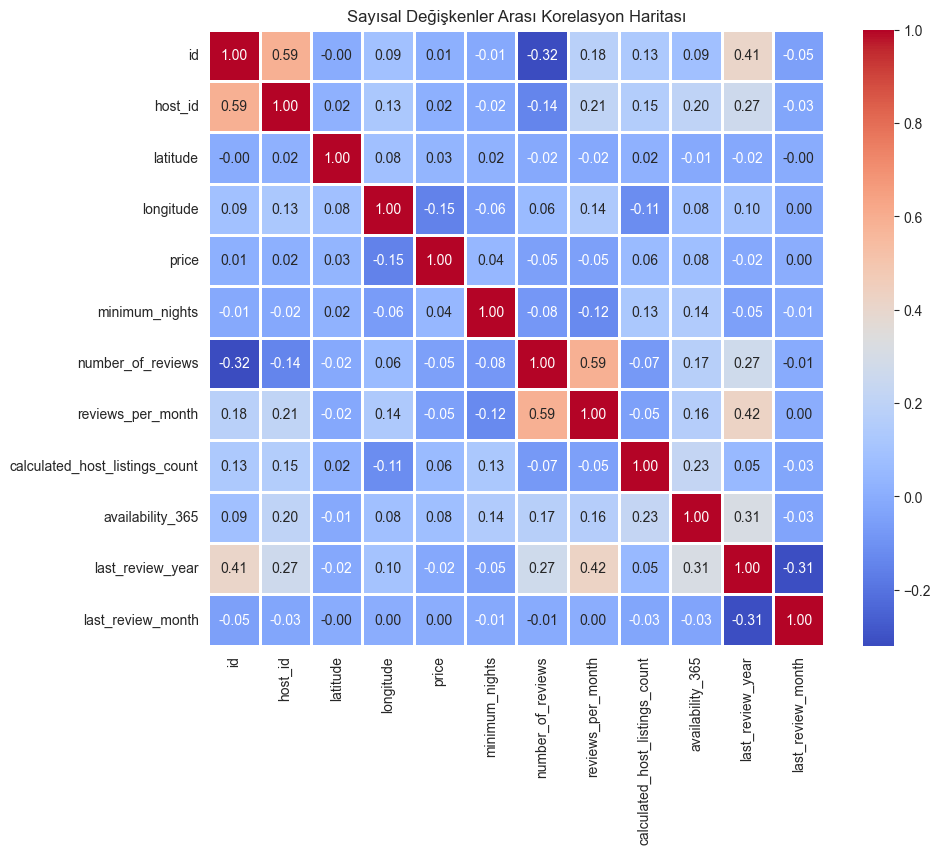

In [10]:
# Sayısal (numeric) değişkenleri seçelim ve korelasyon matrisini hesaplayalım
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()

# Korelasyon Isı Haritası
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=1)
plt.title('Sayısal Değişkenler Arası Korelasyon Haritası')
plt.show()

# Not: Yüksek pozitif (>0.5) veya yüksek negatif (<-0.5) değerler güçlü ilişkiye işaret eder. 
# Örneğin reviews_per_month ile number_of_reviews arasında beklenen bir ilişki mevcut. Fiyatla ise belirgin güçlü bir doğrusal ilişki hiçbir değişkende yok gibi duruyor (doğrusal olmayan dinamikler devrede).

**Sonuçların Yorumlanması:**
Korelasyon haritasındaki sayılar, -1 ile 1 arasında değişir; 1'e ne kadar yakınsa değişkenler arasında o kadar doğru orantı (biri artarken diğeri artar), -1'e yakınsa ters orantı mevcuttur. 0'a yakın sayılar ise direkt bir ilişkinin olmadığını gösterir. Çıktıdan anlıyoruz ki: "fiyat (`price`)" ile inceleme sayısı (`reviews`) gibi değişkenler arasında belirgin, güçlü bir doğrusal matematiksel bağ yok (0'a yakın skorlar). Beklendiği üzere, `reviews_per_month` ile `number_of_reviews` arasında pozitif bir ilişki var.

## 3. Görselleştirmeler

In [11]:
# Semtlere Göre Dağılım
fig = px.pie(df, names='neighbourhood_group', title="Semtlere (Borough) Göre İlan Dağılımı")
fig.show()

**Sonuçların Yorumlanması:**
Buradaki pasta grafiği (`Pie Chart`), Airbnb ilanlarının büyük çoğunluğunun Manhattan ve Brooklyn bölgesinde yığıldığını bize gösteriyor. Kalan diğer bölgeler olan Queens veya Staten Island pastada çok daha ufak dilimlere (% azınlığa) sahip. Bu durum pazarı iki ana ilçenin domine ettiğini gösterir.

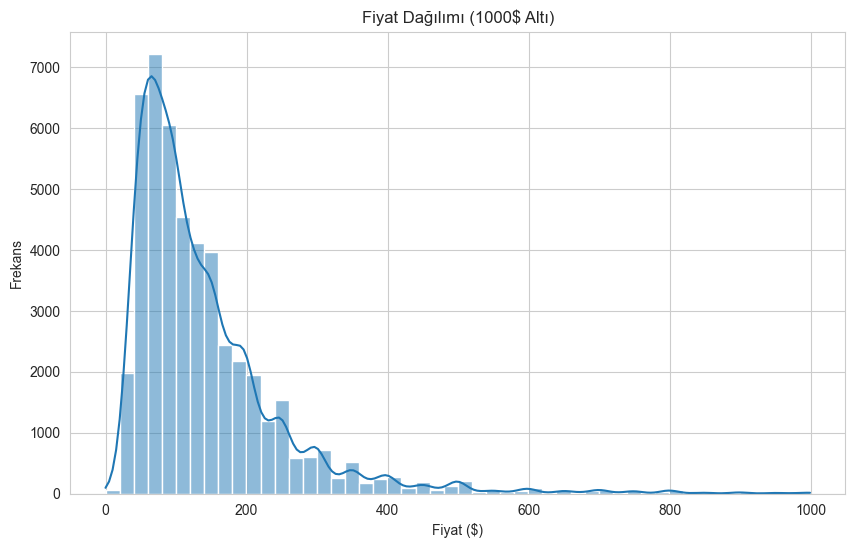

In [12]:
# Fiyat Dağılımı (Logaritmik Ölçek Daha İyi Sonuç Verir Fiyatlarda)
df_filtered = df[df['price'] < 1000] # Aşırı uç noktaları görsel için filtrele
sns.histplot(df_filtered['price'], bins=50, kde=True)
plt.title('Fiyat Dağılımı (1000$ Altı)')
plt.xlabel('Fiyat ($)')
plt.ylabel('Frekans')
plt.show()

**Sonuçların Yorumlanması:**
Histogram (sütun grafiği) sayesinde fiyatın nasıl dağıldığını (hangi aralıkların daha çok tercih edildiğini) anlarız. Görüldüğü kadarıyla $1000'ın çok altında yoğun bir yığılma mevcuttur (özellikle $50-$200 arası). Bu fiyat spektrumu, ortalama bir kullanıcının veya pazarın "yaygın" beklentisini temsil ediyor.

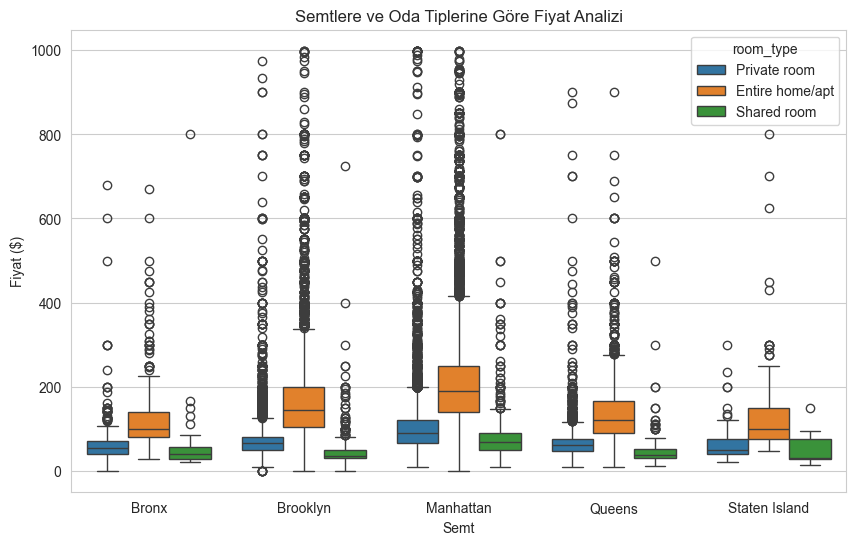

In [13]:
# Oda Tipine Göre Fiyat Karşılaştırması
plt.figure(figsize=(10,6))
sns.boxplot(data=df_filtered, x='neighbourhood_group', y='price', hue='room_type')
plt.title('Semtlere ve Oda Tiplerine Göre Fiyat Analizi')
plt.xlabel('Semt')
plt.ylabel('Fiyat ($)')
plt.show()

**Sonuçların Yorumlanması:**
Kutu grafiği (`Boxplot`), medyan (kutu içindeki çizgi), %25-%75 çeyreklikleri (kutu sınırları) ve "aykırı değer" uçlarını (üst tellerden taşan noktalar) aynı anda gösterir. Farklı semtlere göre `Bütün Ev (Entire home/apt)` en yüksek fiyat skalasında seyrederken, `Paylaşımlı (Shared)` ya da `Özel (Private)` oda tipleri görece daha uygun maliyetlere sahiptir. Görselden net bir analizle oda tiplerinin fiyat üzerinde belirleyici gücü olduğunu saptıyoruz.

## 4. Uzaysal (Geospatial) Görünümler
Oda fiyatlarını harita üzerinde göstermek.

In [14]:
# Harita scatter
sample = df_filtered.sample(2000, random_state=42)
fig = px.scatter_mapbox(sample, lat="latitude", lon="longitude", color="price",
                        size="number_of_reviews", hover_name="name", 
                        color_continuous_scale=px.colors.sequential.Plasma, zoom=9,
                        mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

**Sonuçların Yorumlanması:**
Dağılım haritasında (`Scatter Mapbox`), verideki coğrafi koordinatları (`latitude`, `longitude`) gerçek bir New York haritasına oturtarak ısı-renk farklılıklarından fiyat yoğunluklarını izliyoruz. Manhattan civarlarında fiyatı yüksek gösteren noktaların fazlalığı göze çarpıyor. Noktaların büyüklüğü (inceleme sayısı), kalabalık renk kümelenmeleri ise arzın (ev fazlalığının) hangi sokaklarda kümelendiğini görmemizi sağlıyor.